# SkyView Aerial Landscape — CNN Classifier
**STA6704 Group Project**

Sections are organized so you can tweak hyperparameters in **Section 3** and re-run only from there downward. An experiment runner in **Section 9** lets you compare multiple configs on a single plot.

---
## 1. Imports

In [3]:
import os
import random
import pathlib
import time
import copy
import warnings
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

print('Imports OK.')

Imports OK.


---
## 2. Device Check (GPU / CPU)

In [4]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'GPU detected : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')   # Apple Silicon
    print('Apple MPS (Metal) GPU detected.')
else:
    DEVICE = torch.device('cpu')
    print('No GPU found — running on CPU (training will be slower).')

print(f'Active device : {DEVICE}')

GPU detected : NVIDIA GeForce RTX 5090
VRAM         : 34.2 GB
Active device : cuda


---
## 3.  HYPERPARAMETERS  ← adjust here

Change any value in this cell, then **Run All Below** to retrain with the new config.

In [62]:
# ── Data ──────────────────────────────────────────────────────────────────────
IMAGE_SIZE   = 256        # pixels (square); try 64, 128, 224
TRAIN_SPLIT  = 0.70       # fraction of data for training
VAL_SPLIT    = 0.15       # fraction for validation  (rest = test)
RANDOM_SEED  = 42

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 16         # try 16, 32, 64
NUM_EPOCHS   = 60         # try 10, 20, 40
LEARNING_RATE = 1e-4      # try 1e-2, 1e-3, 1e-4
WEIGHT_DECAY  = 1e-5      # L2 regularisation; try 0, 1e-4, 1e-3

# ── Optimizer ─────────────────────────────────────────────────────────────────
OPTIMIZER    = 'adam'     # 'adam' | 'sgd' | 'adamw'
MOMENTUM     = 0.9        # used only when OPTIMIZER == 'sgd'

# ── LR Scheduler ──────────────────────────────────────────────────────────────
SCHEDULER    = 'step'     # 'step' | 'cosine' | 'none'
STEP_SIZE    = 7          # (step scheduler) decay LR every N epochs
GAMMA        = 0.5        # (step scheduler) decay factor

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_TYPE   = 'custom_cnn'   # 'custom_cnn' | 'resnet18' | 'resnet50'
PRETRAINED   = True           # use ImageNet weights (ignored for custom_cnn)
DROPOUT      = 0.4            # dropout rate in classifier head; try 0.2, 0.4, 0.5

# ── Custom CNN depth (ignored for resnet*) ────────────────────────────────────
CNN_CHANNELS = [32, 64, 128, 256]   # conv filters per block; add/remove blocks freely

# ── Augmentation ──────────────────────────────────────────────────────────────
USE_AUGMENTATION = True   # flip True/False to toggle augmentation

# ── Early Stopping ────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE = 5   # stop if val loss doesn't improve for N epochs; 0 = off

print('Hyperparameters set.')

Hyperparameters set.


---
## 4. Download Dataset & Locate Image Root

In [63]:
dataset_path = kagglehub.dataset_download('ankit1743/skyview-an-aerial-landscape-dataset')
root = pathlib.Path(dataset_path)

# Step into single subdirectory if present
subdirs = [p for p in root.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    root = subdirs[0]

classes = sorted(p.name for p in root.iterdir() if p.is_dir())
NUM_CLASSES = len(classes)
print(f'Image root   : {root}')
print(f'Num classes  : {NUM_CLASSES}')
print(f'Classes      : {classes}')

Image root   : C:\Users\sahil\.cache\kagglehub\datasets\ankit1743\skyview-an-aerial-landscape-dataset\versions\1\Aerial_Landscapes
Num classes  : 15
Classes      : ['Agriculture', 'Airport', 'Beach', 'City', 'Desert', 'Forest', 'Grassland', 'Highway', 'Lake', 'Mountain', 'Parking', 'Port', 'Railway', 'Residential', 'River']


---
## 5. Transforms & DataLoaders

In [64]:
# ImageNet normalisation stats work well even for custom CNNs trained from scratch
_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

aug_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

base_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

train_tf = aug_transforms if USE_AUGMENTATION else base_transforms
eval_tf  = base_transforms

# Load full dataset once with eval transforms, then re-wrap train split with aug transforms
full_dataset = datasets.ImageFolder(root=str(root), transform=eval_tf)

total       = len(full_dataset)
n_train     = int(total * TRAIN_SPLIT)
n_val       = int(total * VAL_SPLIT)
n_test      = total - n_train - n_val

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

# Override transform for the training subset
train_ds.dataset = copy.deepcopy(full_dataset)
train_ds.dataset.transform = train_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = full_dataset.classes
print(f'Train / Val / Test : {len(train_ds)} / {len(val_ds)} / {len(test_ds)}')
print(f'Batches per epoch  : {len(train_loader)}')

Train / Val / Test : 8400 / 1800 / 1800
Batches per epoch  : 525


---
## 6. Model Definition

In [65]:
class CustomCNN(nn.Module):
    """Simple configurable ConvNet. Block count & filter sizes set by CNN_CHANNELS."""

    def __init__(self, in_channels: int, channel_list: list, num_classes: int, dropout: float):
        super().__init__()
        blocks = []
        prev = in_channels
        for ch in channel_list:
            blocks += [
                nn.Conv2d(prev, ch, kernel_size=5, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(ch, ch, kernel_size=5, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            prev = ch
        self.features = nn.Sequential(*blocks)
        self.pool     = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(prev * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


def build_model(model_type: str, num_classes: int, pretrained: bool,
                dropout: float, cnn_channels: list) -> nn.Module:
    if model_type == 'custom_cnn':
        return CustomCNN(3, cnn_channels, num_classes, dropout)

    weights_arg = 'IMAGENET1K_V1' if pretrained else None
    if model_type == 'resnet18':
        m = models.resnet18(weights=weights_arg)
    elif model_type == 'resnet50':
        m = models.resnet50(weights=weights_arg)
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    # Freeze backbone when using pretrained weights (fine-tune only the head)
    if pretrained:
        for param in m.parameters():
            param.requires_grad = False

    in_features = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )
    return m


model = build_model(MODEL_TYPE, NUM_CLASSES, PRETRAINED, DROPOUT, CNN_CHANNELS).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model         : {MODEL_TYPE}')
print(f'Total params  : {total_params:,}')
print(f'Trainable     : {trainable_params:,}')

Model         : custom_cnn
Total params  : 5,360,879
Trainable     : 5,360,879


---
## 7. Loss, Optimizer & Scheduler

In [66]:
criterion = nn.CrossEntropyLoss()

trainable_params_iter = filter(lambda p: p.requires_grad, model.parameters())

if OPTIMIZER == 'adam':
    optimizer = optim.Adam(trainable_params_iter, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER == 'adamw':
    optimizer = optim.AdamW(trainable_params_iter, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER == 'sgd':
    optimizer = optim.SGD(trainable_params_iter, lr=LEARNING_RATE,
                          momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
else:
    raise ValueError(f'Unknown optimizer: {OPTIMIZER}')

if SCHEDULER == 'step':
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
elif SCHEDULER == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
else:
    scheduler = None

print(f'Optimizer : {OPTIMIZER}  |  Scheduler : {SCHEDULER}')

Optimizer : adam  |  Scheduler : step


---
## 8. Training Loop

In [67]:
def run_epoch(model, loader, criterion, optimizer, device, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
best_weights  = None
patience_ctr  = 0

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>9}  {'Train Acc':>9}  {'Val Acc':>8}  {'LR':>9}")
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, DEVICE, training=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer, DEVICE, training=False)

    current_lr = optimizer.param_groups[0]['lr']
    if scheduler:
        scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        patience_ctr  = 0
        tag = ' *'
    else:
        patience_ctr += 1
        tag = ''

    elapsed = time.time() - t0
    print(f"{epoch:6d}  {train_loss:10.4f}  {val_loss:9.4f}  {train_acc:9.4f}  {val_acc:8.4f}  {current_lr:9.2e}{tag}")

    # Early stopping
    if EARLY_STOP_PATIENCE > 0 and patience_ctr >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f'\nBest val loss: {best_val_loss:.4f}')

 Epoch  Train Loss   Val Loss  Train Acc   Val Acc         LR
-----------------------------------------------------------------
     1      1.7210     1.1123     0.4337    0.6389   1.00e-04 *
     2      1.2749     0.9518     0.5810    0.7011   1.00e-04 *
     3      1.1136     0.8005     0.6387    0.7356   1.00e-04 *
     4      1.0055     0.8257     0.6727    0.7144   1.00e-04
     5      0.8965     0.7546     0.7079    0.7461   1.00e-04 *
     6      0.8088     0.7201     0.7393    0.7617   1.00e-04 *
     7      0.7446     0.5285     0.7544    0.8272   1.00e-04 *
     8      0.6098     0.4540     0.8000    0.8494   5.00e-05 *
     9      0.5676     0.4330     0.8121    0.8517   5.00e-05 *
    10      0.5392     0.3970     0.8214    0.8656   5.00e-05 *
    11      0.5148     0.3789     0.8273    0.8767   5.00e-05 *
    12      0.4865     0.3474     0.8413    0.8811   5.00e-05 *
    13      0.4710     0.3195     0.8421    0.8917   5.00e-05 *
    14      0.4495     0.3347     0.8506  

---
## 9. Performance Graphs

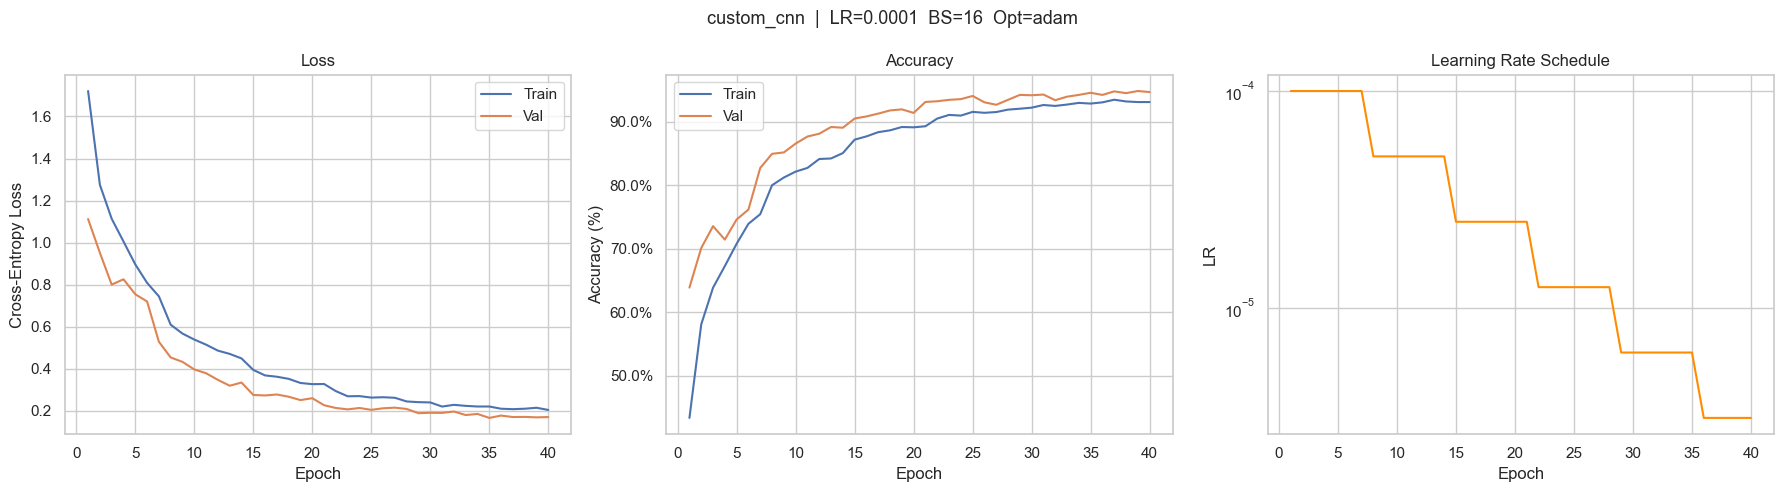

In [68]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_TYPE}  |  LR={LEARNING_RATE}  BS={BATCH_SIZE}  Opt={OPTIMIZER}', fontsize=13)

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_ran, [a * 100 for a in history['train_acc']], label='Train')
axes[1].plot(epochs_ran, [a * 100 for a in history['val_acc']],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
axes[1].legend()

# Learning rate schedule
axes[2].plot(epochs_ran, history['lr'], color='darkorange')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

---
## 10. Test Set Evaluation

In [69]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy: {test_acc * 100:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy: 94.28%

              precision    recall  f1-score   support

 Agriculture       0.94      0.94      0.94       122
     Airport       0.80      0.89      0.84       112
       Beach       0.98      0.96      0.97       137
        City       0.93      0.96      0.95       120
      Desert       0.95      0.97      0.96       120
      Forest       0.98      0.97      0.97       100
   Grassland       0.98      0.98      0.98       128
     Highway       0.97      0.94      0.95       124
        Lake       0.94      0.92      0.93       130
    Mountain       0.95      0.95      0.95       137
     Parking       0.99      0.93      0.96        96
        Port       0.94      0.98      0.96       114
     Railway       0.90      0.88      0.89       112
 Residential       1.00      0.96      0.98       115
       River       0.91      0.91      0.91       133

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
wei

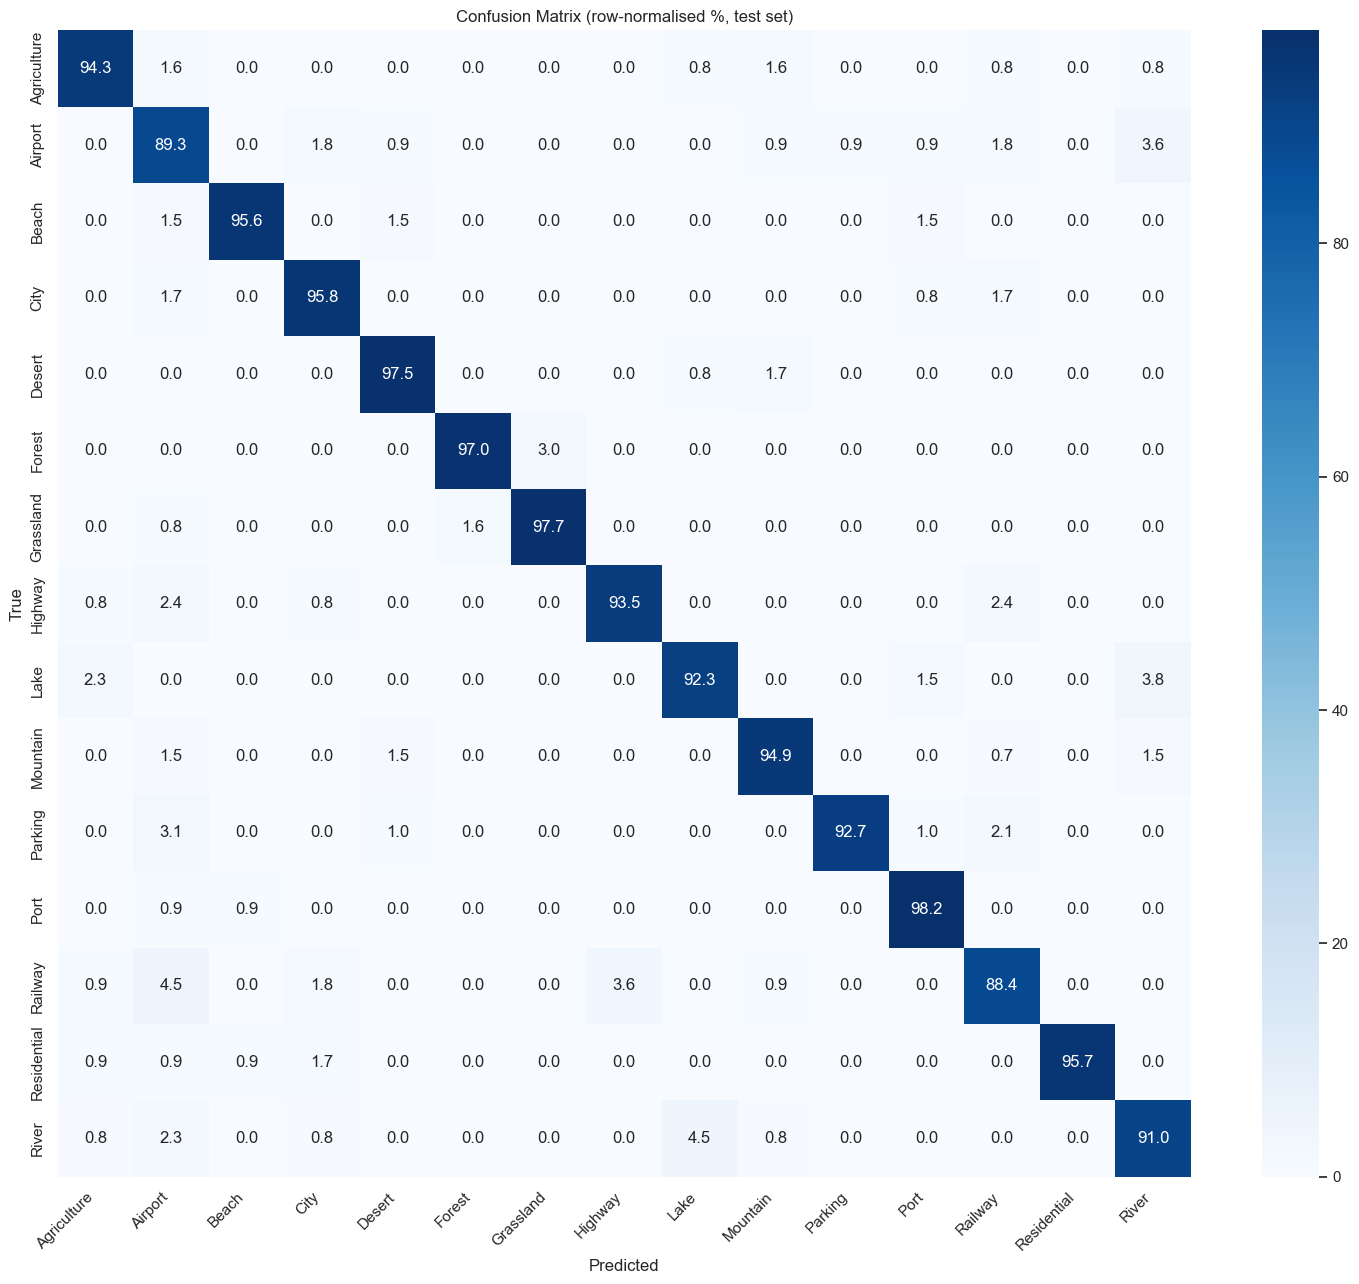

In [70]:
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 2)))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix (row-normalised %, test set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top Misclassified Images

The grid below shows the images the model was **most confidently wrong about**, ranked by softmax confidence in the incorrect prediction. Title format: `True → Predicted (confidence%)`.

In [ ]:
TOP_N = 20   # number of misclassified images to display; adjust freely

# Denormalise a tensor image back to [0,1] for display
_inv_mean = torch.tensor([[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225]])
_inv_std  = torch.tensor([[1 / 0.229, 1 / 0.224, 1 / 0.225]])

def denorm(t):
    t = t.clone().permute(1, 2, 0)          # C,H,W → H,W,C
    t = t / _inv_std + (-_inv_mean / _inv_std)  # undo normalize
    return t.clamp(0, 1).numpy()

model.eval()
mistakes = []   # (confidence, image_tensor, true_idx, pred_idx)

with torch.no_grad():
    for images, labels in test_loader:
        outputs  = model(images.to(DEVICE))
        probs    = torch.softmax(outputs, dim=1).cpu()
        preds    = probs.argmax(1)

        for img, prob, pred, true in zip(images, probs, preds, labels):
            if pred != true:
                conf = prob[pred].item()
                mistakes.append((conf, img, true.item(), pred.item()))

# Sort: highest confidence in wrong prediction first
mistakes.sort(key=lambda x: x[0], reverse=True)
top = mistakes[:TOP_N]

print(f'Total misclassified on test set : {len(mistakes)} / {len(test_ds)} '
      f'({len(mistakes)/len(test_ds)*100:.1f}%)')
print(f'Displaying top {len(top)} most confidently wrong images.\n')

cols = 5
rows = (len(top) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.5))
axes = axes.flatten()

for ax, (conf, img, true_idx, pred_idx) in zip(axes, top):
    ax.imshow(denorm(img))
    true_name = CLASS_NAMES[true_idx]
    pred_name = CLASS_NAMES[pred_idx]
    ax.set_title(
        f'True: {true_name}\nPred: {pred_name}\n({conf*100:.1f}% conf)',
        fontsize=8,
        color='crimson',
    )
    ax.axis('off')

# Hide any unused subplot slots
for ax in axes[len(top):]:
    ax.axis('off')

fig.suptitle(f'Top {len(top)} Most Confidently Misclassified Images (test set)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-class error summary ───────────────────────────────────────────────────
error_counts = collections.Counter(
    (CLASS_NAMES[t], CLASS_NAMES[p]) for _, _, t, p in mistakes
)
top_pairs = error_counts.most_common(10)
print('\nTop confusion pairs (True → Predicted : count)')
for (true_name, pred_name), cnt in top_pairs:
    print(f'  {true_name:15s} → {pred_name:15s} : {cnt}')